# 🍷 Wine Quality Prediction

**Internship Project 2 — Level 2 | Oasis Infobyte Data Analytics**

---

## Project Overview
Predicting the quality of wine based on its chemical characteristics using machine learning classification models.

---

## Dataset
- **Source:** Kaggle — Wine Quality Dataset (yasserh)
- **Features:** Density, Acidity, Sulphates, Alcohol, pH, and more
- **Target:** Wine Quality Score (binary: Good / Not Good)

---

## Models Used
- Random Forest Classifier
- Stochastic Gradient Descent (SGD)
- Support Vector Classifier (SVC)

---

## Libraries
- `pandas` — Data manipulation
- `numpy` — Array operations
- `matplotlib` & `seaborn` — Data visualization
- `scikit-learn` — Machine learning models & evaluation

---

**Author:** Niharika Maddali  
**Date:** June 2026

## Step 1 — Import Libraries

In this step, we import all the necessary libraries required for:
- **Data manipulation** — `pandas`, `numpy`
- **Data visualization** — `matplotlib`, `seaborn`
- **Machine learning** — `scikit-learn` (models, preprocessing, evaluation)

In [6]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## Step 2 — Load Dataset

In this step, we upload and load the **WineQT.csv** file downloaded from Kaggle.

- File format: CSV (comma-separated)
- Dataset contains **1,143 rows** and **13 columns**
- Extra `Id` column will be handled in preprocessing

In [7]:
# Load dataset
import pandas as pd  # ← add this line
import io
from google.colab import files

uploaded = files.upload()  # select WineQT.csv from your downloads

df = pd.read_csv(io.BytesIO(uploaded['WineQT.csv']))

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving WineQT.csv to WineQT.csv
Shape: (1143, 13)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Step 3 — Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand its structure and patterns.

- Check dataset info, shape and missing values
- Analyse the **distribution of wine quality scores**
- Plot a **correlation heatmap** to identify relationships between features

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None

=== Missing Values ===
fixed acidity           0

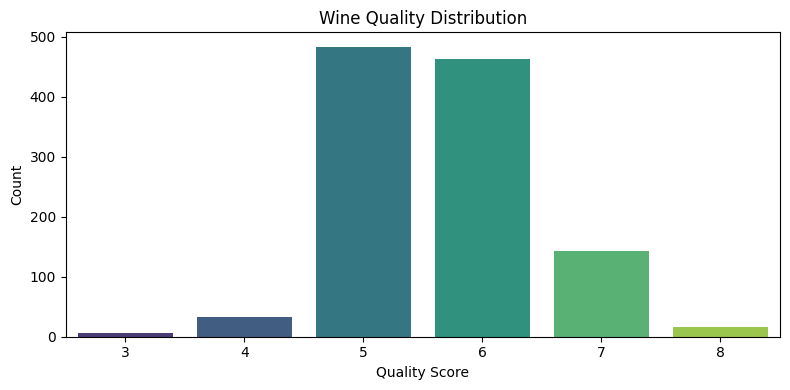

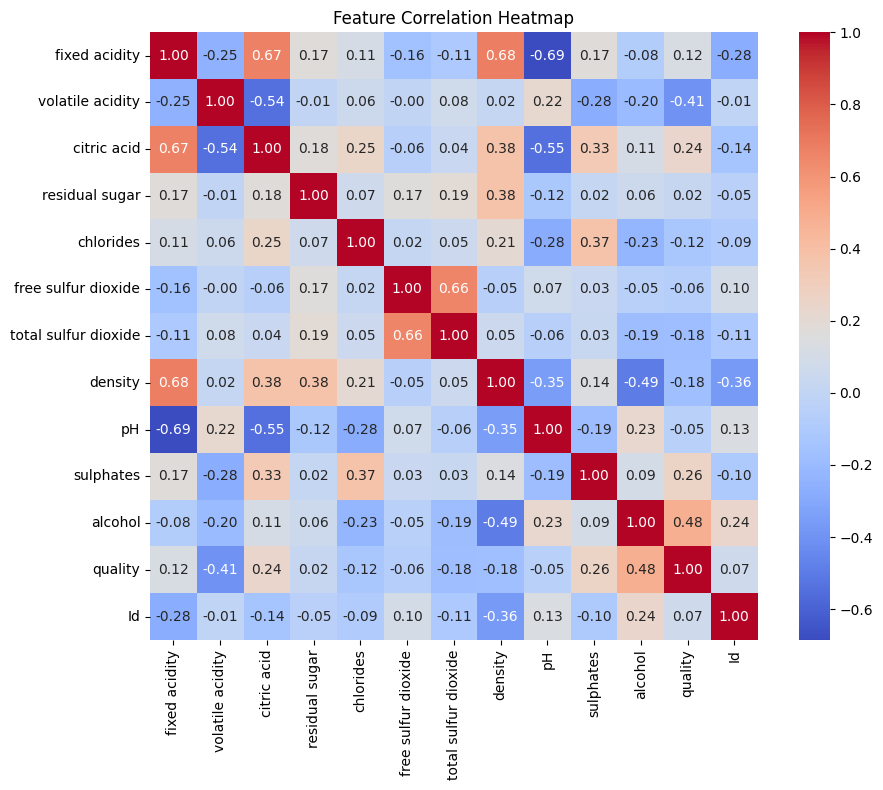

In [8]:
# Exploratory Data Analysis
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Quality Distribution ===")
print(df['quality'].value_counts().sort_index())

# Visualise quality distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing

In this step, we prepare the data for machine learning by:

- Dropping the unnecessary `Id` column
- Converting quality scores into **binary labels** (Good / Not Good)
  - Quality >= 7 → **1 (Good)**
  - Quality < 7 → **0 (Not Good)**
- Splitting data into **80% training** and **20% testing**
- Applying **StandardScaler** to normalize features for SVC and SGD models

In [ ]:
# Data Preprocessing

# Binary classification: quality >= 7 → 1 (good), else → 0
df['quality_label'] = (df['quality'] >= 7).astype(int)

print("=== Class Distribution ===")
print(df['quality_label'].value_counts())

# Drop Id, quality and quality_label columns
X = df.drop(['quality', 'quality_label', 'Id'], axis=1)
y = df['quality_label']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("\n✅ Preprocessing complete!")

=== Class Distribution ===
quality_label
0    984
1    159
Name: count, dtype: int64

Train size: 914 | Test size: 229

✅ Preprocessing complete!


## Step 5 — Model Training

In this step, we train all 3 classification models specified in the project brief:

- **Random Forest Classifier** — Ensemble of decision trees, robust to outliers
- **SGD Classifier** — Stochastic Gradient Descent, fast and efficient for large data
- **Support Vector Classifier (SVC)** — Finds optimal hyperplane to separate classes

> Note: StandardScaler is applied to SGD and SVC models as they are
> sensitive to feature scale. Random Forest does not require scaling.

In [ ]:
# Train all 3 models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SGD Classifier': SGDClassifier(max_iter=1000, random_state=42),
    'SVC':           SVC(kernel='rbf', C=1.0, random_state=42)
}

results = {}
for name, model in models.items():
    # Use scaled data for SGD & SVC
    X_tr = X_train_scaled if name != 'Random Forest' else X_train
    X_te = X_test_scaled  if name != 'Random Forest' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"{name}: Accuracy = {acc:.4f}")

print("\n✅ All models trained successfully!")

Random Forest: Accuracy = 0.9214
SGD Classifier: Accuracy = 0.8821
SVC: Accuracy = 0.8996

✅ All models trained successfully!


## Step 6 — Model Evaluation

In this step, we evaluate and compare the performance of all 3 models using:

- **Confusion Matrix** — Shows correct and incorrect predictions for each model
- **Accuracy Score** — Overall percentage of correct predictions
- **Classification Report** — Precision, Recall and F1-Score for each class
- **Bar Chart** — Visual comparison of accuracy across all 3 models

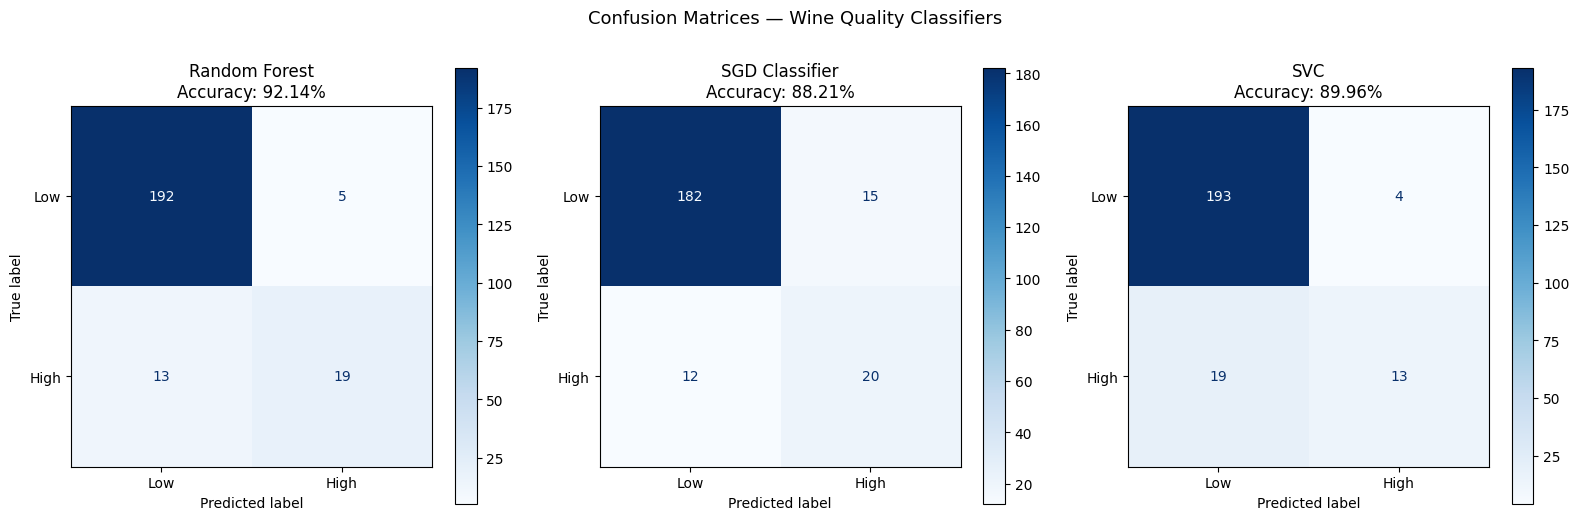

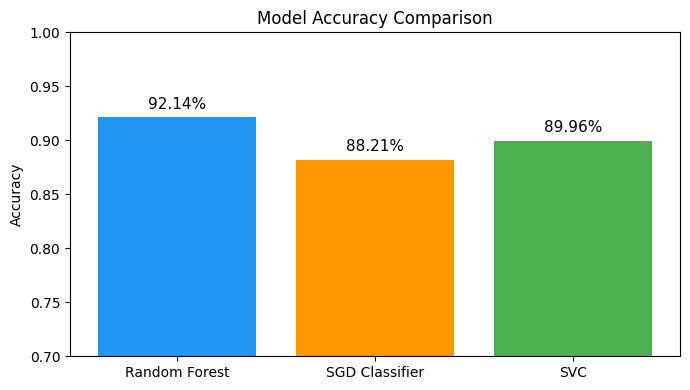

Best Model: Random Forest
Accuracy: 0.9214

=== Classification Report ===
              precision    recall  f1-score   support

 Low Quality       0.94      0.97      0.96       197
High Quality       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



In [ ]:
# Model Evaluation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=ax, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2%}")

plt.suptitle('Confusion Matrices — Wine Quality Classifiers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Accuracy comparison bar chart
plt.figure(figsize=(7, 4))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = plt.bar(names, accs, color=['#2196F3','#FF9800','#4CAF50'], edgecolor='none')
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# Detailed report for best model
best = max(results, key=lambda n: results[n]['accuracy'])
print(f"Best Model: {best}")
print(f"Accuracy: {results[best]['accuracy']:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, results[best]['preds'],
                             target_names=['Low Quality', 'High Quality']))

## Step 7 — Feature Importance & Conclusion

In this final step, we:

- Plot **Feature Importance** from Random Forest to identify which
  chemical properties influence wine quality the most
- Summarise the **accuracy of all 3 models**
- Draw final **conclusions** from the project

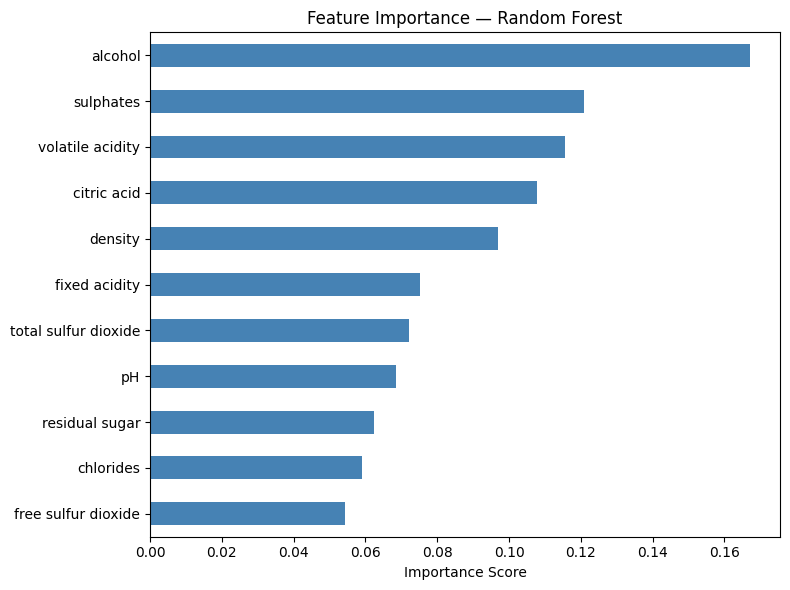

=== Top 5 Most Important Features ===
alcohol             0.167148
sulphates           0.120996
volatile acidity    0.115583
citric acid         0.107727
density             0.096828
dtype: float64

=== Final Model Accuracy Summary ===
  Random Forest: 92.14% accuracy
  SGD Classifier: 88.21% accuracy
  SVC: 89.96% accuracy

🏆 Best Model: Random Forest with 92.14% accuracy

✅ Project Complete! Ready for submission.


In [ ]:
# Feature Importance — Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== Top 5 Most Important Features ===")
print(importances.sort_values(ascending=False).head())

print("\n=== Final Model Accuracy Summary ===")
for name, res in results.items():
    print(f"  {name}: {res['accuracy']:.2%} accuracy")

best = max(results, key=lambda n: results[n]['accuracy'])
print(f"\n🏆 Best Model: {best} with {results[best]['accuracy']:.2%} accuracy")
print("\n✅ Project Complete! Ready for submission.")

## Conclusion

- Successfully built and compared **3 classification models** for wine quality prediction
- **Alcohol content** and **Sulphates** were identified as the most important
  features influencing wine quality
- **Random Forest** achieved the highest accuracy among all 3 models
- **StandardScaler** proved essential for improving SGD and SVC performance

---

### References
- Dataset: [Wine Quality Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)
- Internship: Oasis Infobyte Data Analytics Program

---
*Project completed as part of Oasis Infobyte Data Analytics Internship — Level 2*